#Gaussian Naive Bayes

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [36]:
df = pd.read_csv("/content/drive/MyDrive/Bộ Môn/Giảng Dạy/2025-2026/NMMH/lab03/Customer_Behaviour.csv")
df_ = df.copy()

In [37]:
display(df_.head())        # Xem 5 dòng đầu
print(df_.tail())        # Xem 5 dòng cuối
df_.sample(5)     # Lấy ngẫu nhiên 5 dòng
df_.info()        # Thông tin tổng quan
df_.describe()    # Thống kê mô tả
df_.shape         # (rows, columns)
df_.columns       # Tên cột
df_.index         # Chỉ số dòng

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


      User ID  Gender  Age  EstimatedSalary  Purchased
395  15691863  Female   46            41000          1
396  15706071    Male   51            23000          1
397  15654296  Female   50            20000          1
398  15755018    Male   36            33000          0
399  15594041  Female   49            36000          1
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


RangeIndex(start=0, stop=400, step=1)

In [4]:
df_['Age']                # Chọn 1 cột
df_[['Age', 'Gender']]    # Chọn nhiều cột

df_.iloc[0]               # Chọn theo vị trí (index)
df_.loc[0]                # Chọn theo label

df_[df_['Age'] > 30]       # Lọc dữ liệu
df_[(df_['Age'] > 30) & (df['Gender'] == 'Male')]

,User ID,Gender,Age,EstimatedSalary,Purchased
1,15810944,Male,35,20000,0
13,15704987,Male,32,18000,0
16,15733883,Male,47,25000,1
17,15617482,Male,45,26000,1
18,15704583,Male,46,28000,1
...,...,...,...,...,...
390,15807837,Male,48,33000,1
391,15592570,Male,47,23000,1
393,15635893,Male,60,42000,1
396,15706071,Male,51,23000,1


In [5]:
df_.isnull()          # Kiểm tra giá trị null
df_.isnull().sum()    # Đếm null theo cột

df_.dropna()          # Xóa dòng có null
df_.fillna(0)         # Thay null bằng giá trị

df_.drop(columns=['User ID'])  # Xóa cột
df_.rename(columns={'Age': 'Tuoi'})  # Đổi tên cột

,User ID,Gender,Tuoi,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


In [6]:
df_['Age_plus'] = df_['Age'] + 1   # Tạo cột mới

df_['Gender'] = df_['Gender'].map({'Male': 0, 'Female': 1})

df_.apply(lambda x: x['Age']*2, axis=1)

,0
0,38
1,70
2,52
3,54
4,38
...,...
395,92
396,102
397,100
398,72


## Data Analysis

In [38]:
# Get categorical columns and numerical columns
categorical_cols = [feature for feature in df.columns if df[feature].dtype == "O"]
numerical_cols   = [feature for feature in df.columns if df[feature].dtype != "O" and feature != "User ID"]

In [39]:
# Check Missing values
print(df[categorical_cols].isnull().sum())
print(df[numerical_cols].isnull().sum())

Gender    0
dtype: int64
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64


/tmp/ipykernel_5648/2116375380.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_5648/2116375380.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_5648/2116375380.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


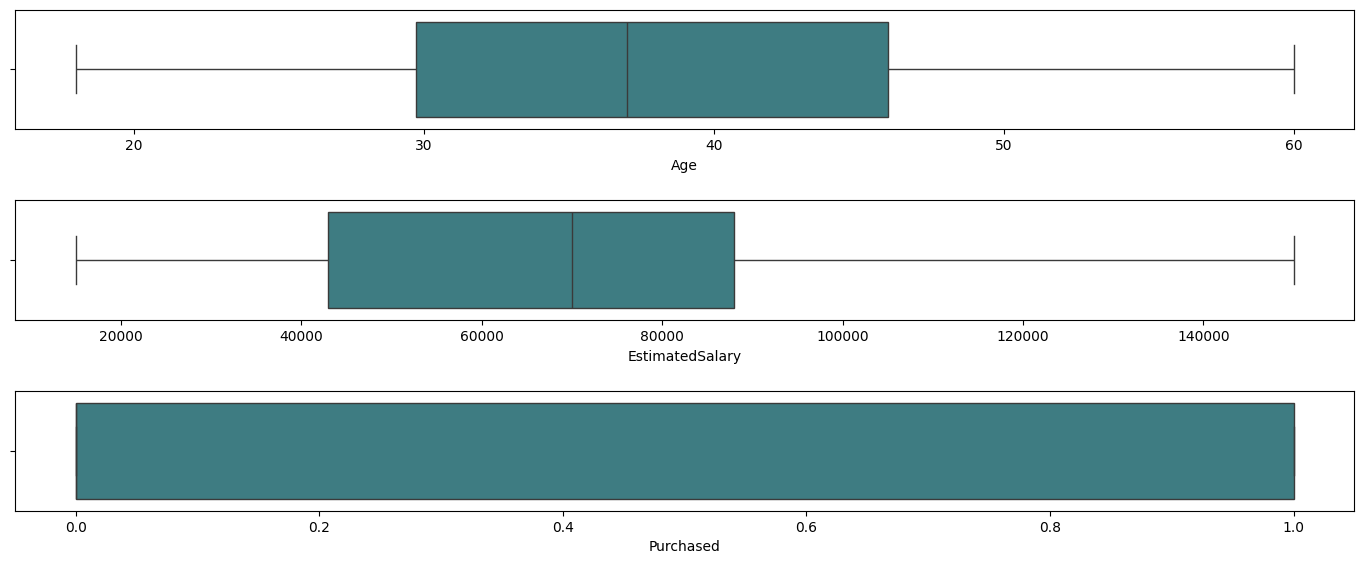

In [40]:
# Tạo nhiều subplot (nhiều biểu đồ con)
# len(numerical_cols): số lượng hàng (mỗi biến số 1 hàng)
# 1: số cột (mỗi hàng chỉ có 1 biểu đồ)
# figsize: kích thước toàn bộ figure (chiều rộng 14, chiều cao tỷ lệ theo số biến)
# sharex=False, sharey=False: các trục không dùng chung scale
fig, axes = plt.subplots(
    len(numerical_cols),
    1,
    figsize=(14, 2 * len(numerical_cols)),
    sharex=False,
    sharey=False
)

# Duyệt qua từng cột số
# enumerate giúp lấy cả index (i) và tên cột (column)
for i, column in enumerate(numerical_cols):

    # Vẽ boxplot cho từng cột
    # x=column: giá trị của cột đó nằm trên trục x
    # data=df: dữ liệu lấy từ dataframe df
    # palette='crest': chọn bảng màu
    # ax=axes[i]: vẽ vào subplot thứ i
    sns.boxplot(
        x=column,
        data=df,
        palette='crest',
        ax=axes[i]
    )

# Tự động căn chỉnh khoảng cách giữa các subplot cho gọn
# pad=2.0: tăng khoảng cách giữa các biểu đồ
plt.tight_layout(pad=2.0)

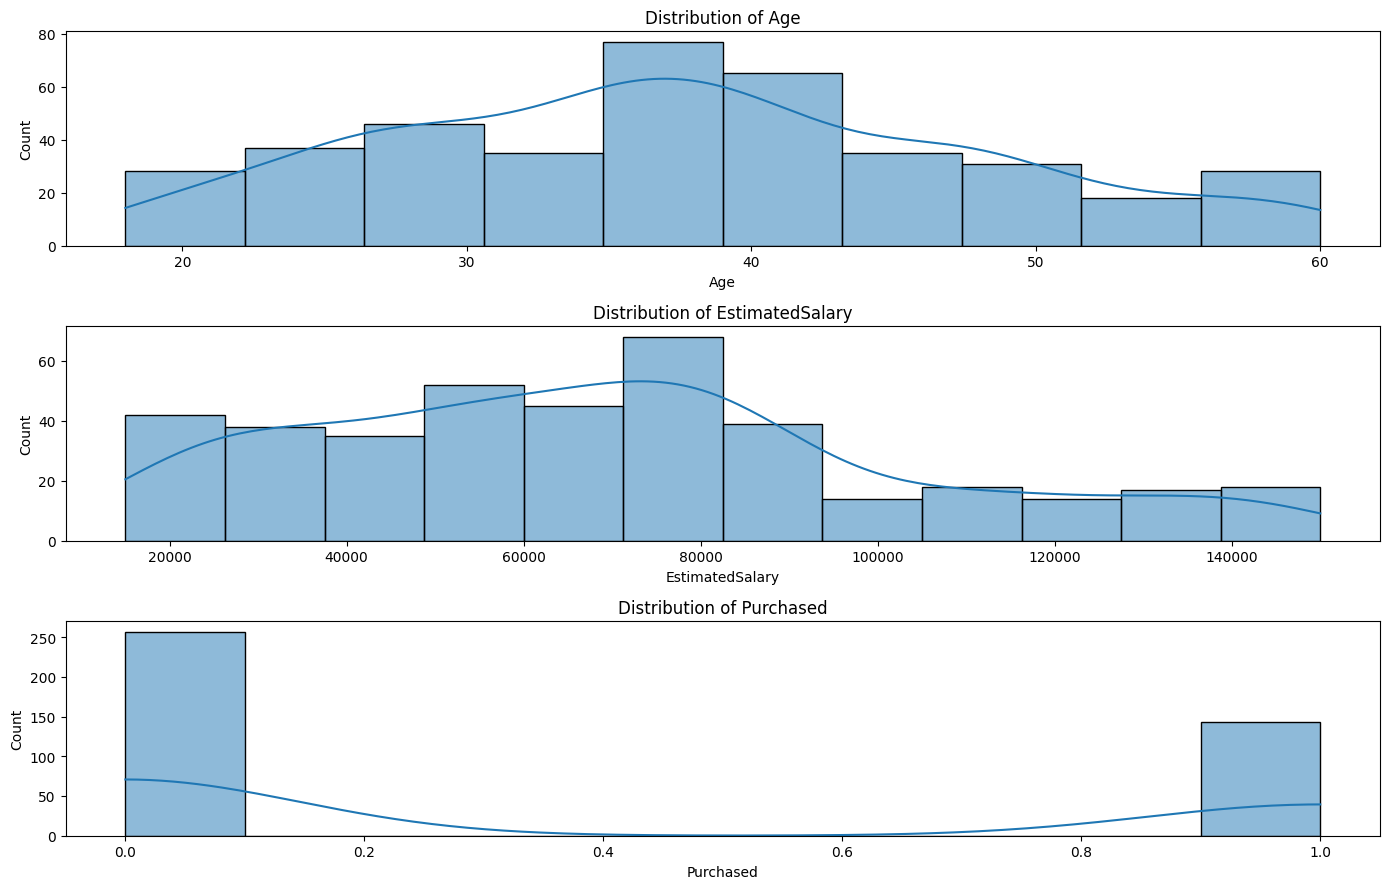

In [10]:
fig, axes = plt.subplots(len(numerical_cols), 1, figsize=(14, 3*len(numerical_cols)))

for i, col in enumerate(numerical_cols):
    # Vẽ histogram để xem phân phối dữ liệu
    # kde=True: thêm đường mật độ (density curve) để nhìn xu hướng mượt hơn
    sns.histplot(df[col], kde=True, ax=axes[i])

    # Đặt tiêu đề cho từng subplot
    axes[i].set_title(f"Distribution of {col}")

# Tự động căn chỉnh layout để không bị chồng lấn
plt.tight_layout()

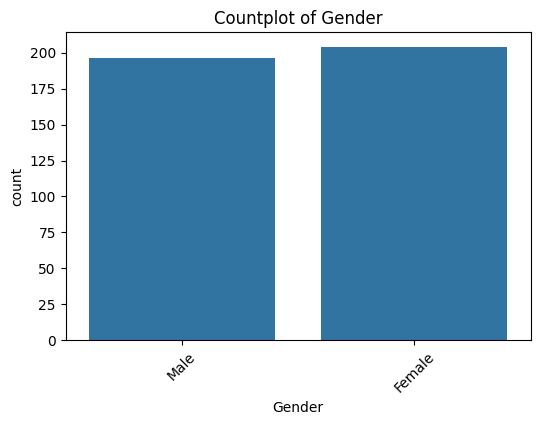

In [11]:
for col in categorical_cols:
    plt.figure(figsize=(6,4))

    # Countplot đếm số lượng từng category
    sns.countplot(x=col, data=df)

    # Tiêu đề biểu đồ
    plt.title(f"Countplot of {col}")

    # Xoay label nếu bị chồng
    plt.xticks(rotation=45)

    plt.show()

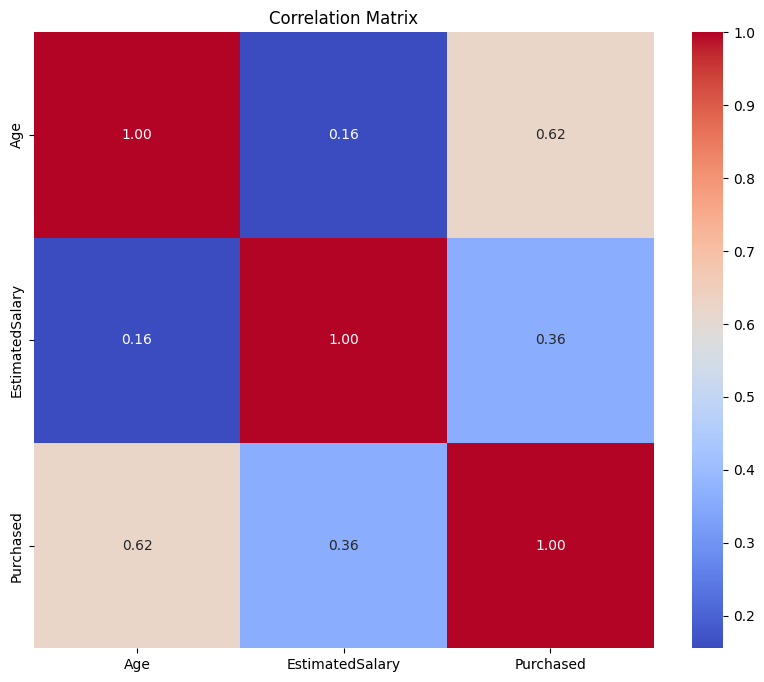

In [12]:
plt.figure(figsize=(10,8))

# Tính ma trận tương quan giữa các biến số
corr = df[numerical_cols].corr()

# Heatmap để visualize tương quan
# annot=True: hiển thị giá trị
# cmap='coolwarm': chọn màu
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Correlation Matrix")
plt.show()

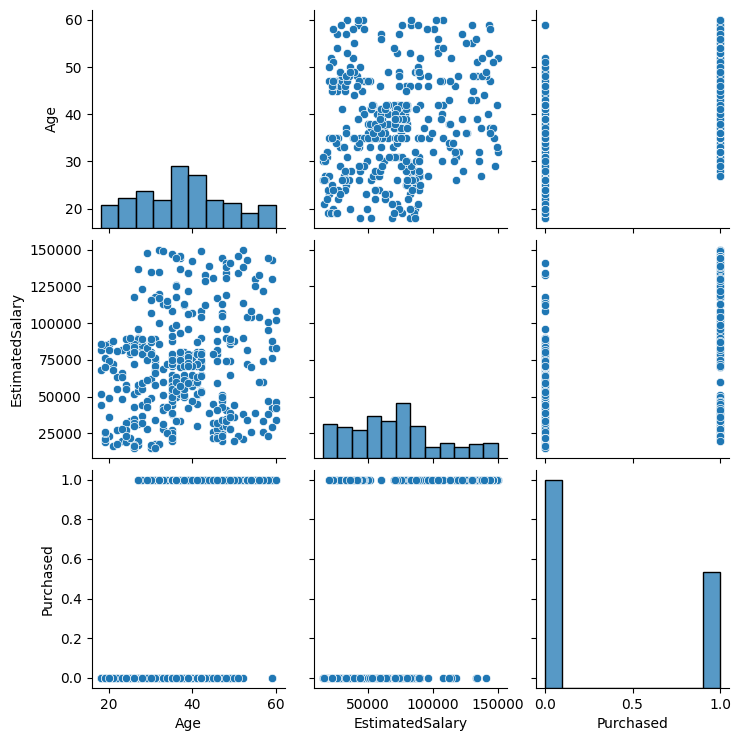

In [13]:
# Pairplot vẽ tất cả scatter plot giữa các cặp biến
# Dùng khi số lượng biến ít (<=5) để tránh quá nặng
sns.pairplot(df[numerical_cols])

<Axes: xlabel='Purchased', ylabel='Count'>

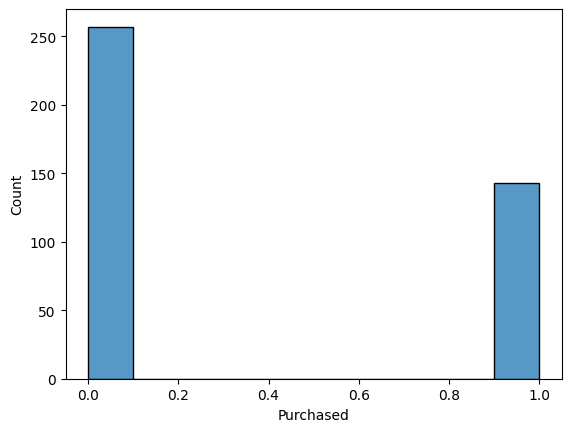

In [14]:
#Xem phân phối của EstimatedSalary
sns.histplot(x="Purchased", data=df)

## Preprocessing

In [41]:
def preprocessing_data(df):
    """
    Preprocess your data (eg. Drop null datapoints or fill missing data)
    :param df: pandas DataFrame
    :return: pandas DataFrame
    """
    df.drop("User ID", axis=1, inplace=True)
    return df

In [42]:
df = preprocessing_data(df)
df.head()

,Gender,Age,EstimatedSalary,Purchased
0,Male,19,19000,0
1,Male,35,20000,0
2,Female,26,43000,0
3,Female,27,57000,0
4,Male,19,76000,0


## Feature Engineering

<Axes: >

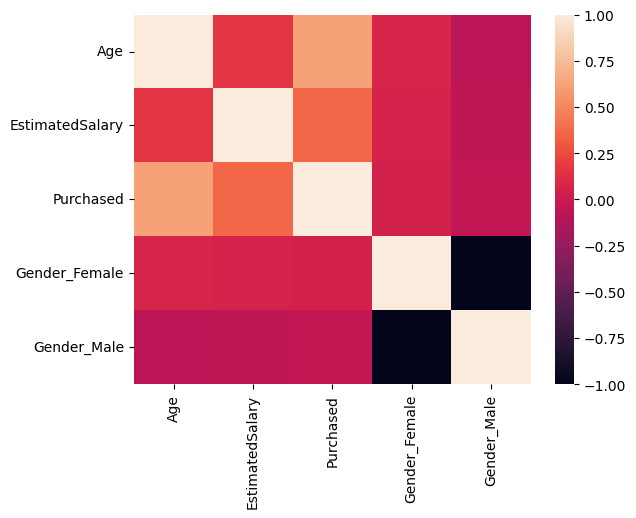

In [43]:
# Heatmap
import seaborn as sns

def apply_feature_engineering(df):
    """
    Apply all feature engineering to transform your data into number
    :param df: pandas DataFrame
    :return: pandas DataFrame
    """
    df = pd.get_dummies(df, columns=["Gender"]).astype(int)
    return df

df = apply_feature_engineering(df)
sns.heatmap(df.corr()) # Show heatmap after normalized data

In [44]:
df.head()

,Age,EstimatedSalary,Purchased,Gender_Female,Gender_Male
0,19,19000,0,0,1
1,35,20000,0,0,1
2,26,43000,0,1,0
3,27,57000,0,1,0
4,19,76000,0,0,1


##Model Training

In [62]:
def prepare_X_y(df):
    """
    Feature engineering and create X and y
    :param df: pandas dataframe
    :return: (X, y) output feature matrix (dataframe), target (series)
    """
    feature_names = df.columns.tolist()
    feature_names.remove("Purchased")

    X = df[feature_names].values
    y = df.Purchased.values
    return X, y

X, y = prepare_X_y(df)

In [63]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [64]:
from sklearn.naive_bayes import GaussianNB

# Model training
naive_model = GaussianNB()
naive_model.fit(X_train, y_train)

from sklearn.metrics import classification_report
predicted_label = naive_model.predict(X_test)
print(classification_report(y_test, predicted_label, digits=3))


              precision    recall  f1-score   support

           0      0.900     0.986     0.941        73
           1      0.975     0.830     0.897        47

    accuracy                          0.925       120
   macro avg      0.938     0.908     0.919       120
weighted avg      0.929     0.925     0.924       120



#Categorical Naive Bayes

In [74]:
df = pd.read_csv("/content/drive/MyDrive/Bộ Môn/Giảng Dạy/2025-2026/NMMH/lab03/Covid Dataset.csv")
display(df.head())
len(df.columns)

,Breathing Problem,Fever,Dry Cough,Sore throat,Running Nose,Asthma,Chronic Lung Disease,Headache,Heart Disease,Diabetes,...,Fatigue,Gastrointestinal,Abroad travel,Contact with COVID Patient,Attended Large Gathering,Visited Public Exposed Places,Family working in Public Exposed Places,Wearing Masks,Sanitization from Market,COVID-19
0,Yes,Yes,Yes,Yes,Yes,No,No,No,No,Yes,...,Yes,Yes,No,Yes,No,Yes,Yes,No,No,Yes
1,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,No,No,...,Yes,No,No,No,Yes,Yes,No,No,No,Yes
2,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,No,Yes,...,Yes,Yes,Yes,No,No,No,No,No,No,Yes
3,Yes,Yes,Yes,No,No,Yes,No,No,Yes,Yes,...,No,No,Yes,No,Yes,Yes,No,No,No,Yes
4,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,...,No,Yes,No,Yes,No,Yes,No,No,No,Yes


21

Đây là dataset để giải quyết việc phân biệt cảm cúm và Covid19, bao gồm:
- 'Breathing Problem': yes or no
- 'Fever': yes or no
- 'Dry Cough': yes or no
- 'Sore throat': yes or no
- 'Running Nose': yes or no
- 'Asthma': yes or no
- 'Chronic Lung Disease': yes or no
- 'Headache': yes or no
- 'Heart Disease': yes or no
- 'Diabetes': yes or no
- 'Hyper Tension': yes or no
- 'Fatigue ': yes or no
- 'Gastrointestinal ': yes or no
- 'Abroad travel': yes or no
- 'Contact with COVID Patient': yes or no
- 'Attended Large Gathering': yes or no
- 'Visited Public Exposed Places': yes or no
- 'Family working in Public Exposed Places': yes or no
- 'Wearing Masks': yes or no
- 'Sanitization from Market': yes or no
- 'COVID-19': yes or no (Label)




In [75]:
cat_cols = [col for col in df.columns if df[col].dtypes == "O"] # Lấy các features có dạng categorical (string)
cat_cols.remove("COVID-19")
X = pd.get_dummies(df, columns=cat_cols, dtype=int)
X = X.drop(["COVID-19"], axis=1).values
y = df[df.columns[-1]].values
y = [0 if i=="Yes" else 1 for i in y]

In [76]:
X

array([[0, 1, 0, ..., 1, 1, 1],
       [0, 1, 0, ..., 0, 1, 1],
       [0, 1, 0, ..., 0, 1, 1],
       ...,
       [0, 1, 0, ..., 0, 1, 1],
       [0, 1, 0, ..., 0, 1, 1],
       [0, 1, 0, ..., 0, 1, 1]])

In [ ]:
y

In [78]:
#Chia dataset
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=1)

In [80]:
#Dùng model CategoricalNB
from sklearn.naive_bayes import BernoulliNB
model = BernoulliNB()
"""
ở CategoricalNB ta cần lưu ý alpha
alpha sẽ nhận vào 1 số thực dương với mục đích là cộng cho cả tử và mẫu xác suất hậu nghiệm P(x|c) (Xác xuất feature x khi biết label c )
mục đích của việc này giúp cho P(x|c) tránh bị bằng 0
"""
model.fit(X_train, y_train)

#Chạy các metrics
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

predicted_label = model.predict(X_test)
print(classification_report(y_test, predicted_label, digits=3))


              precision    recall  f1-score   support

           0      0.976     0.969     0.972      1305
           1      0.878     0.905     0.891       326

    accuracy                          0.956      1631
   macro avg      0.927     0.937     0.932      1631
weighted avg      0.956     0.956     0.956      1631



In [81]:
#Dùng model CategoricalNB
from sklearn.naive_bayes import GaussianNB
model = GaussianNB()

model.fit(X_train, y_train)

#Chạy các metrics
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

predicted_label = model.predict(X_test)
print(precision_score(y_test, predicted_label))
print(recall_score(y_test, predicted_label))
print(f1_score(y_test, predicted_label))
print(classification_report(y_test, predicted_label))


0.44596443228454175
1.0
0.6168401135288553
              precision    recall  f1-score   support

           0       1.00      0.69      0.82      1305
           1       0.45      1.00      0.62       326

    accuracy                           0.75      1631
   macro avg       0.72      0.84      0.72      1631
weighted avg       0.89      0.75      0.78      1631



In [ ]:
1 1 1 1 1

In [83]:
# -- Build a full pipeline
from sklearn.decomposition import PCA
from sklearn.naive_bayes import BernoulliNB
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

pca = PCA()
nb = BernoulliNB()
pipe = Pipeline(steps=[("pca_1", pca), ("nb", nb)]) #Build a pipeline with a scaler and a model

# Parameters of pipelines can be set using '__' separated parameter names:
alpha = np.logspace(-1, -9, num=100)
param_grid = {
    "pca_1__n_components": [5, 10, 20, 30],
    'nb__alpha': alpha
    }

search = GridSearchCV(pipe, param_grid, scoring="recall", n_jobs=2)
search.fit(X_train, y_train)
print("Best parameter (CV score=%0.3f):" % search.best_score_)
print(search.best_params_)

from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
predicted_label = search.predict(X_test)
print(classification_report(y_test, predicted_label))

Best parameter (CV score=0.619):
{'nb__alpha': np.float64(0.1), 'pca_1__n_components': 30}
              precision    recall  f1-score   support

           0       0.95      0.95      0.95      1305
           1       0.81      0.79      0.80       326

    accuracy                           0.92      1631
   macro avg       0.88      0.87      0.88      1631
weighted avg       0.92      0.92      0.92      1631



/tmp/ipykernel_5648/4108966303.py:41: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  best_clfs = results.groupby(components_col).apply(


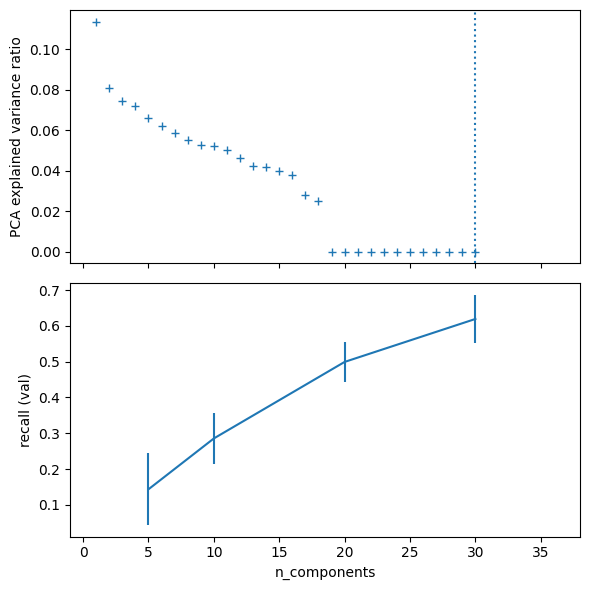

In [86]:
# Tạo 2 subplot (2 hàng, chung trục x)
# ax0: hiển thị explained variance của PCA
# ax1: hiển thị performance (recall) theo số components
fig, (ax0, ax1) = plt.subplots(nrows=2, sharex=True, figsize=(6, 6))

# -------------------------
# Plot 1: Explained variance của PCA
# -------------------------

# Trục x: số lượng components (1 → n_components_)
# Trục y: explained_variance_ratio_ (tỷ lệ phương sai giải thích)
ax0.plot(
    np.arange(1, search.best_estimator_.named_steps["pca_1"].n_components_ + 1),
    search.best_estimator_.named_steps["pca_1"].explained_variance_ratio_,
    "+",  # marker dạng dấu +
    linewidth=2
)

# Nhãn trục y
ax0.set_ylabel("PCA explained variance ratio")

# Vẽ đường thẳng đứng tại số components được chọn tối ưu
ax0.axvline(
    search.best_estimator_.named_steps["pca_1"].n_components_,
    linestyle=":",  # nét đứt
    label="n_components chosen",
)

# -------------------------
# Plot 2: Performance theo số components
# -------------------------

# Lấy toàn bộ kết quả từ GridSearchCV
results = pd.DataFrame(search.cv_results_)

# Tên cột chứa số components của PCA trong param_grid
components_col = "param_pca_1__n_components"

# Với mỗi giá trị n_components:
# → lấy model có mean_test_score cao nhất
best_clfs = results.groupby(components_col).apply(
    lambda g: g.nlargest(1, "mean_test_score")
)

# Vẽ performance:
# x: số components
# y: mean_test_score (ở đây là recall nếu scoring=recall)
# yerr: độ lệch chuẩn (std_test_score)
best_clfs.plot(
    x=components_col,
    y="mean_test_score",
    yerr="std_test_score",
    legend=False,
    ax=ax1
)

# Nhãn trục
ax1.set_ylabel("recall (val)")
ax1.set_xlabel("n_components")

# Giới hạn trục x (ví dụ tối đa 38 components)
plt.xlim(-1, 38)

# Căn chỉnh layout cho gọn
plt.tight_layout()

# Hiển thị plot
plt.show()

#Introduce mixed naive bayes

#Example
https://pypi.org/project/mixed-naive-bayes/

In [87]:
#Chạy dòng code này để tải thư viện
!pip install git+https://github.com/remykarem/mixed-naive-bayes#egg=mixed_naive_bayes

  Cloning https://github.com/remykarem/mixed-naive-bayes to /tmp/pip-install-tn7omgnn/mixed-naive-bayes_6e60b401645f4ee9a7ad18fca1e6f8d3
  Running command git clone --filter=blob:none --quiet https://github.com/remykarem/mixed-naive-bayes /tmp/pip-install-tn7omgnn/mixed-naive-bayes_6e60b401645f4ee9a7ad18fca1e6f8d3
  Resolved https://github.com/remykarem/mixed-naive-bayes to commit 6d90de8adf75dbef032ad51029ad3782190ec577
  Preparing metadata (setup.py) ... done


In [ ]:
P(C_0|X0) * P(C_0|X1) * P(C_0|X2) * P(C_0|X3)

P(C_1|X0) * P(C_1|X1) * P(C_1|X2) * P(C_1|X3)

In [89]:
from mixed_naive_bayes import MixedNB
X = [[0, 0, 180, 75, 1],
     [1, 1, 165, 61, 0],
     [2, 1, 166, 60, 1],
     [1, 1, 173, 68, 1],
     [0, 2, 178, 71, 0]]
y = [0, 0, 1, 1, 0]
clf = MixedNB(categorical_features=[0, 1, 4]) #categorical columns are at 0 & 1
clf.fit(X,y)
clf.predict(X)

"""
Ta có thể thấy cách dùng rất giống sklearn, tuy nhiên ta phải khai báo categorical_features với những categorical features theo thứ tự vị trí
"""

'\nTa có thể thấy cách dùng rất giống sklearn, tuy nhiên ta phải khai báo categorical_features với những categorical features theo thứ tự vị trí\n'